# Libraries

In [32]:
import pandas as pd
import numpy as np
import os
import matplotlib.font_manager as fm
import time
import warnings

# Plotting Libs
import matplotlib.pyplot as plt 
from sklearn.tree import plot_tree
from xgboost import plot_importance
import shap

# Scaler Libs
from sklearn.preprocessing import MinMaxScaler

# CV Libs
from sklearn.model_selection import GridSearchCV 
import statsmodels.api as sm

# Model Libs
from sklearn.linear_model import LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Accuracy Libs
from sklearn.metrics import accuracy_score , classification_report, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score
from sklearn.metrics import matthews_corrcoef
from sklearn.metrics import RocCurveDisplay
from sklearn.metrics import PrecisionRecallDisplay
from sklearn.metrics import average_precision_score
from sklearn.metrics import balanced_accuracy_score
from sklearn.metrics import f1_score

# Resampling Libs
from sklearn.model_selection import train_test_split
from imblearn.under_sampling import RandomUnderSampler

# VIF
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant

# Load Data

In [33]:
start_time = time.time()

In [34]:
df1 = pd.read_pickle(r".\df_dummies\df1_dummies.pkl")
df2 = pd.read_pickle(r".\df_dummies\df2_dummies.pkl")
df3 = pd.read_pickle(r".\df_dummies\df3_dummies.pkl")
df4 = pd.read_pickle(r".\df_dummies\df4_dummies.pkl")

# Accuracy tests/ Roc Function


In [35]:
def accuracy(dfi, i, model, X_test, y_test, y_pred, title):
    print(f"Model : Phase {i} - {title}")

    print("\na).\nClassification Report :")
    class_rep = classification_report(y_test, y_pred)
    print(class_rep)
    print("\nb).\nF1 Score :")
    f1 = f"{f1_score(y_test, y_pred, average='weighted'):.2f}"
    print(f1)

    print("\nc).\nBalanced Accuracy Score :")
    acc_bal = f"{balanced_accuracy_score(y_test, y_pred) * 100:.2f}%"
    print(acc_bal)

    print("\nd).\nMatthews Correlation Coefficient (MCC) :")
    mcc = f"{matthews_corrcoef(y_test, y_pred):.2f}"
    print(mcc)

    print("\nd).\nPlots :")
    fig , ax = plt.subplots(figsize = (20, 6), nrows = 1, ncols = 3)

    ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax = ax[0]);
    RocCurveDisplay.from_estimator(model, X_test, y_test, ax = ax[1], name = f'{title}'); #  pos_label=1, # Completed = 0, Terminated = 1
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test, ax=ax[2], name=f'{title}') # pos_label=1, 
    
    print(f"ROC AUC : {roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}") # Predict Probabilities for accurate ROC Auc")
    print(f"PR AUC : {average_precision_score(y_test, model.predict_proba(X_test)[:, 1]).round(3)}")

    plt.suptitle(f"Phase {i} - {title}", fontsize = 11, fontweight = 'bold')

    # Confusion Matrix
    ax[0].set_title("1. Confusion Matrix", fontsize = 10, fontweight = 'bold')
    ax[0].set_xlabel("Predicted Label", fontsize = 10, fontweight = 'bold')
    ax[0].set_ylabel("True Label", fontsize = 10, fontweight = 'bold')
    
    # Roc Curve
    ax[1].set_title("2. ROC Curve" , fontsize = 10, fontweight = 'bold')
    ax[1].set_ylabel("Sensitivity - Recall (TPR)", fontsize = 10, fontweight = 'bold')
    ax[1].set_xlabel("1 - Specificity (FPR) ", fontsize = 10, fontweight = 'bold')

    # PR Cruve
    ax[2].set_title("3. PR Curve", fontsize = 10, fontweight = 'bold')
    ax[2].set_ylabel("Precision (PPV)", fontsize = 10, fontweight = 'bold')
    ax[2].set_xlabel("Sensitivity - Recall (TPR)", fontsize = 10, fontweight = 'bold')

    plt.show()      
    plt.close(fig)  

    return acc_bal, class_rep, mcc, f1

# SHAP Function
- SHAP Summary PLot:
- Impact on the prediction (how much a feature contributes to pushing the prediction left (negative) or right (positive)).
- Blue = low feature value.
- Red = high feature value.

- Example: Enrollment_Log:
- High values (red) → strong negative SHAP values → push prediction to Completed.
- Low values (blue) → positive SHAP values → push toward Terminated.
- SHAP X-axis shows how much each feature pushes the prediction toward class 0 or 1, in log-odds space. (value -5)

In [36]:
# SHAP dataset overview
def fun_shap(i, model, X_test, model_str):
    X_test_sam = shap.sample(X_test, 100)
    explainer = shap.Explainer(model.predict, X_test_sam)
    shap_values = explainer(X_test_sam)

    # Files/Paths 
    model_str = model_str
    folder_shap = "shap_plots"
    os.makedirs(folder_shap, exist_ok=True)
    filename = f"df{i}_{model_str}_shap_plot.png"
    filepath = os.path.join(folder_shap, filename)

#### Summary Plot SHAP --> Global overview 
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=FutureWarning)
        shap.summary_plot(shap_values, X_test_sam, plot_size=(8, 4), max_display = 15, show=False)
    plt.title(f"df{i} - {model_str} - SHAP Summary Plot", fontsize = 12, fontweight="bold", pad = 15)
    plt.xlabel("SHAP value (impact on model output)", fontsize=12, labelpad=15) 

    ax = plt.gca()
    for label in ax.get_yticklabels()[-7:]:
        label.set_fontweight("bold")
    # Save Summary Plot
    fig = plt.gcf()
    fig.savefig(filepath, dpi = 100, bbox_inches = 'tight')
    plt.show()
    plt.close(fig)

#### Waterfall Plot --> 1 data point prediction --> Local overview
    '''plt.figure(figsize = (20, 3), dpi = 100)
    shap.waterfall_plot(shap_values[0], max_display = 10, show = False) 
    plt.title(f"{model_str} SHAP Waterfall Plot", fontsize = 12, fontweight = "bold", pad = 15)
    plt.tight_layout()
    plt.show()'''

#### SHAP mean values - top features
    shap_value_mean = np.abs(shap_values.values).mean(axis=0).round(3)
    shap_important = pd.DataFrame({
        "Feature": X_test_sam.columns,
        f"df{i}_{model_str}_Shap_Mean" : shap_value_mean
    })
    shap_important = shap_important.sort_values(by = f"df{i}_{model_str}_Shap_Mean", ascending=False).head(8).reset_index(drop=True)
    # Save Mean Shap values
    shap_important.to_pickle(f"./shap_plots/df{i}_{model_str}_mean_shap.pkl")
    display(shap_important)
    
    return shap_important


# Data Preparation

## Df Input

In [37]:
display(df1.shape)
display(df2.shape)
display(df3.shape)
display(df4.shape)

(21012, 73)

(19747, 73)

(13317, 73)

(12420, 73)

In [38]:
i = 2
dfi = df2

## X , y

In [39]:
X = dfi.drop(columns = ["Study_Status_Bin"], axis = 1)
y = dfi["Study_Status_Bin"]

# initial X features
X.shape # Check that initial shape of dfi was not changed.
y

2        0
3        0
8        0
12       0
18       0
        ..
66484    0
66488    1
66491    0
66494    0
66497    0
Name: Study_Status_Bin, Length: 19747, dtype: int8

## Train - Test Split

In [40]:
# Train-Test Split
X_train_tts, X_test_tts, y_train_tts, y_test_tts = train_test_split(X, y, test_size = 0.2, stratify = y, random_state = 42)

# Imbalanced 0 row = Compeleted, row 1 = terminated
display(f'Terminated/Completed: {y_train_tts.value_counts().iloc[1]/y_train_tts.value_counts().iloc[0]}') 
display(X_train_tts.shape[0], X_test_tts.shape[0])

# EPV
display(y_train_tts[y_train_tts == 1].sum()/(X_train_tts.shape[1]+1))

'Terminated/Completed: 0.2494661077275963'

15797

3950

43.205479452054796

## Resample
- Datasets are imbalanced towards with the negative class the majority. (i.e. COMPLETED = 0) 
- May induce bias towards majority class. 
- Resample train set only, so model will be correctly trained..
    --> Avoids information leaking to test set. test set always similar to true cases.
- Performance evaluated on unsampled test set, with real data distribution.

In [41]:
res = RandomUnderSampler(sampling_strategy = 'auto', random_state = 42)
X_train_res, y_train_res = res.fit_resample(X_train_tts, y_train_tts) 

# Final train/test ratio
display(f'X_test/X_train : {X_test_tts.shape[0]}/{X_train_res.shape[0]} = {(X_test_tts.shape[0]/X_train_res.shape[0])}')
display(f'X_train_sample/X_train_features = {(X_train_res.shape[1]/X_train_res.shape[0])}')

'X_test/X_train : 3950/6308 = 0.6261889663918834'

'X_train_sample/X_train_features = 0.011414077362079899'

## Scaling
- Scale after resample, similarly to train_test_Split so it wont take the skewed distribution of imbalanced data.
- Scaling always after dataset split

In [42]:
def fun_scale(X_train_res, X_test_tts):
    X_train_sc = X_train_res.copy()
    X_test_sc = X_test_tts.copy()

    cont_cols = [col for col in X_train_sc.columns 
                    if (('counts' in col.lower() or 'log' in col.lower()) and
                        not any(x in col.lower() for x in ['bin', 'categ', 'list']))]
    
    # scaler = StandardScaler(with_mean = True, with_std = True)
    scaler = MinMaxScaler()

    X_train_sc[cont_cols] = pd.DataFrame(scaler.fit_transform(X_train_sc[cont_cols]),
        columns = cont_cols, index=X_train_sc.index)

    X_test_sc[cont_cols] = pd.DataFrame(scaler.transform(X_test_sc[cont_cols]),
        columns = cont_cols, index=X_test_sc.index)
    
    return X_train_sc, X_test_sc

X_train_sc, X_test_sc = fun_scale(X_train_res, X_test_tts)

# check if any continues features appear negative values (Negative values are not meanigful to dataset)
col = [col for col in X_train_sc.columns 
                    if (('_Counts' in col or '_Log' in col) and
                        not any(x in col for x in ['_Bin', '_Categ', '_List']))]
X_train_sc[col].describe().round(2)

,Funder_Counts_Log,Adverse_Counts_Log,Arm_Counts_Log,Enrollment_Counts_Log,City_Counts_Log,"Enrollment_Log_x_Bacterial, Mycoses, Virus",Enrollment_Log_x_Cardiovascular,"Enrollment_Log_x_Digestive System, Nutritional, Metabolic",Enrollment_Log_x_Endocrine System,Enrollment_Log_x_Eye,...,Enrollment_Log_x_Neoplasms,Enrollment_Log_x_Nervous System,"Enrollment_Log_x_Pathological Conditions, Signs, Symptoms","Enrollment_Log_x_Phenomena, Processes","Enrollment_Log_x_Psychiatry, Psychology, Anthropology, Sociology","Enrollment_Log_x_Respiratory, Circulatory","Enrollment_Log_x_Skin, Tissue, Wounds","Enrollment_Log_x_Stomatognathic, Otorhinolaryngologic","Enrollment_Log_x_Urogenital, Pregnancy",Enrollment_Log_x_City_Log
count,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,...,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00,6308.00
mean,0.07,0.21,0.13,0.33,0.18,0.05,0.03,0.09,0.03,0.01,...,0.14,0.06,0.11,0.02,0.06,0.05,0.07,0.01,0.05,0.17
std,0.11,0.25,0.12,0.16,0.22,0.15,0.12,0.21,0.13,0.08,...,0.22,0.16,0.23,0.11,0.17,0.15,0.19,0.07,0.16,0.17
min,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,0.00,0.00,0.00,0.21,0.00,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.05
50%,0.00,0.09,0.13,0.34,0.08,0.00,0.00,0.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.08
75%,0.14,0.42,0.13,0.45,0.33,0.00,0.00,0.00,0.00,0.00,...,0.30,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.25
max,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


## X_train_X_test

In [43]:
X_train = X_train_sc.copy() # 
X_test = X_test_sc.copy()
y_train = y_train_res.copy() #
y_test = y_test_tts.copy()

## Rename

In [44]:
def fun_rename(X_train, X_test, y_train, y_test):

    X_train.columns = X_train.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_(Counts_Log|Counts|Log)', " Count", regex=True)
    X_train.columns = X_train.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_(Bin|Type)', "", regex=True)
    X_train.columns = X_train.columns.str.replace(r'_', " ", regex=True)
    X_train.columns = X_train.columns.str.replace(r", ", " ", regex=True)

    X_test.columns = X_test.columns.str.replace(r'List_|Detail_|Adv_Syst_|Adv_', "", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_(Counts_Log|Counts|Log)', " Count", regex=True)
    X_test.columns = X_test.columns.str.replace(r'Funder_Type', "Funder", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_(Bin|Type)', "", regex=True)
    X_test.columns = X_test.columns.str.replace(r'_', " ", regex=True)
    X_test.columns = X_test.columns.str.replace(r", ", " ", regex=True)


    y_train.name = y_train.name.replace('Study_Status_Bin', 'Study Status')
    y_test.name = y_test.name.replace('Study_Status_Bin', 'Study Status')

    return X_train, X_test, y_train, y_test

X_train, X_test, y_train, y_test = fun_rename(X_train, X_test, y_train, y_test)

X_train.columns.to_list()

['Funder Industry',
 'Funder Count',
 'Placebo',
 'Standard Care',
 'Healthy',
 'Adverse Count',
 'Allocation',
 'Arm Count',
 'Enrollment Count',
 'City Count',
 'Global',
 'Sex MALE',
 'Age ADULT',
 'Age OLDER ADULT',
 'Intervention BIOLOGICAL',
 'Intervention DEVICE',
 'Intervention DRUG',
 'Intervention INTERV UNSPES',
 'Intervention PROCEDURE',
 'Intervention Route Injection',
 'Intervention Route Oral',
 'Intervention Route Surgical',
 'Intervention Route Topical',
 'Conditions Bacterial Mycoses Virus',
 'Conditions Cardiovascular',
 'Conditions Digestive System Nutritional Metabolic',
 'Conditions Endocrine System',
 'Conditions Eye',
 'Conditions Hemic Lymphatic Immune System',
 'Conditions Hereditary Neonatal Abnormalities',
 'Conditions Musculoskeletal Neural',
 'Conditions Neoplasms',
 'Conditions Nervous System',
 'Conditions Pathological Conditions Signs Symptoms',
 'Conditions Phenomena Processes',
 'Conditions Psychiatry Psychology Anthropology Sociology',
 'Conditions R

## Drop Cols

In [45]:
X_vif = add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"]

display(vif_data[vif_data["VIF"] > 5].sort_values(by = 'VIF', ascending = False))

,Feature,VIF
72,Enrollment Count x City Count,19.656730
10,City Count,14.159432
67,Enrollment Count x Psychiatry Psychology Anthr...,13.457968
36,Conditions Psychiatry Psychology Anthropology ...,12.752975
62,Enrollment Count x Musculoskeletal Neural,12.113637
31,Conditions Musculoskeletal Neural,11.614703
55,Enrollment Count x Bacterial Mycoses Virus,10.978474
57,Enrollment Count x Digestive System Nutritiona...,10.874215
64,Enrollment Count x Nervous System,10.867299
33,Conditions Nervous System,10.408780


In [46]:
X_train = X_train.drop(columns = ['Enrollment Count x City Count'], axis = 1) 
# Has collinearity with both cities and enrollment --> Inflates coefs of Cities and Enrollment when precent
X_train = X_train.drop(columns = [col for col in X_train.columns if 'Conditions' in col], axis = 1) 
# Has interaction only with enroll x cond

# X_train = X_train.drop(columns = [col for col in X_train.columns if 'Enrollment Count x' in col], axis = 1) # for checking

X_test = X_test.drop(columns = ['Enrollment Count x City Count'], axis = 1)
X_test = X_test.drop(columns = [col for col in X_test.columns if 'Conditions' in col], axis = 1)

# X_test = X_test.drop(columns = [col for col in X_test.columns if 'Enrollment Count x' in col], axis = 1) # for checking



In [47]:
X_vif = add_constant(X_train)

vif_data = pd.DataFrame()
vif_data["Feature"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

vif_data = vif_data[vif_data["Feature"] != "const"]

display(vif_data[vif_data["VIF"] > 5].sort_values(by = 'VIF', ascending = False))

,Feature,VIF
6,Adverse Count,7.335828
37,DRUG x Funder Industry,6.430784
1,Funder Industry,6.254677
29,Intervention Model PARALLEL,5.098457


## Save for Results

In [48]:
X_train.to_pickle(fr'.\df_models\X_train{i}.pkl')
X_test.to_pickle(fr'.\df_models\X_test{i}.pkl')
y_train.to_pickle(fr'.\df_models\y_train{i}.pkl')
y_test.to_pickle(fr'.\df_models\y_test{i}.pkl')

# Models

## A) Classic Classification

### Logistic (L1)

Model : Phase 2 - Lasso Logistic Regression (L1)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.76      0.83      3161
           1       0.44      0.74      0.55       789

    accuracy                           0.76      3950
   macro avg       0.68      0.75      0.69      3950
weighted avg       0.82      0.76      0.78      3950


b).
F1 Score :
0.78

c).
Balanced Accuracy Score :
74.92%

d).
Matthews Correlation Coefficient (MCC) :
0.42

d).
Plots :
ROC AUC : 0.825
PR AUC : 0.621


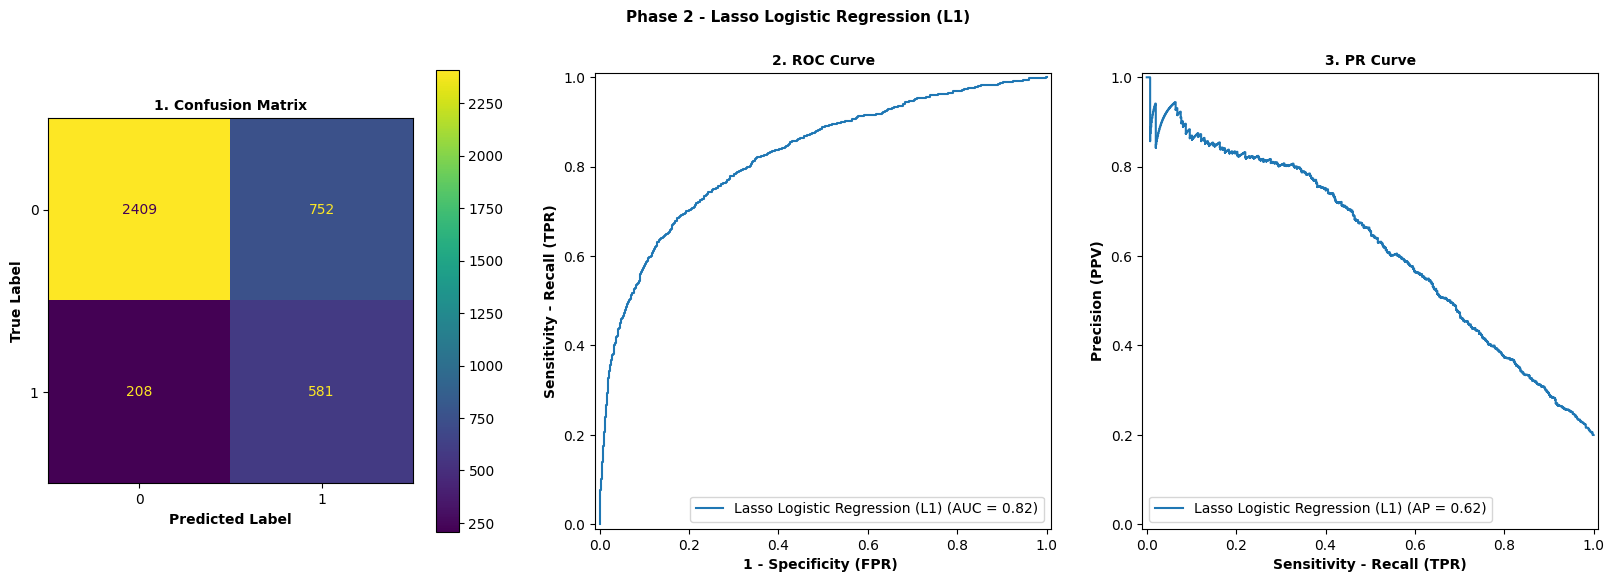

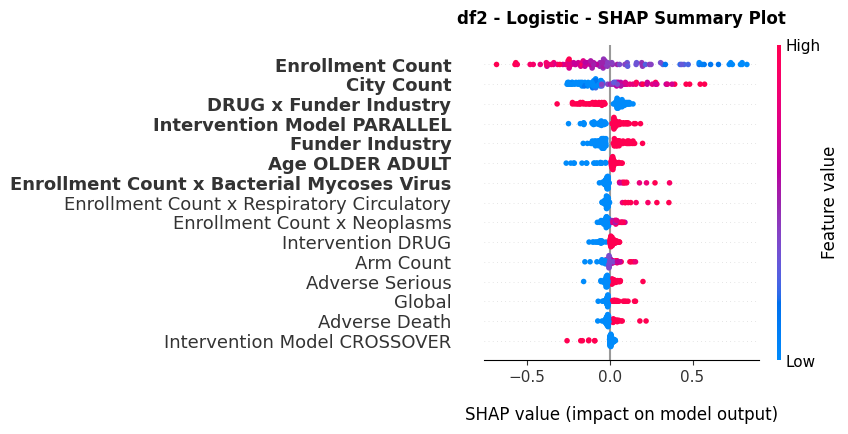

,Feature,df2_Logistic_Shap_Mean
0,Enrollment Count,0.271
1,City Count,0.146
2,DRUG x Funder Industry,0.084
3,Funder Industry,0.064
4,Intervention Model PARALLEL,0.064
5,Age OLDER ADULT,0.038
6,Enrollment Count x Bacterial Mycoses Virus,0.034
7,Enrollment Count x Respiratory Circulatory,0.031


In [49]:
# Model
log_reg = LogisticRegression(penalty = 'l1', max_iter = 5000 , solver = 'saga', class_weight = 'balanced',  random_state = 42)  

# Final Model
log_model = log_reg.fit(X_train, y_train)

# y_pred
y_pred_log_l1 = log_model.predict(X_test)

# Accuracy Score
ba_log, class_log, mcc_log, f1_log = accuracy(dfi, i, log_model, X_test, y_test, y_pred_log_l1, "Lasso Logistic Regression (L1)")

log_shap = fun_shap(i, log_model, X_test, 'Logistic')


### LDA - Linear Discriminant Analysis

- QDA and LDA assume Gaussian distributions.

Best Parameters : {'n_components': 1, 'shrinkage': None}
Best Estimator : LinearDiscriminantAnalysis(n_components=1, solver='lsqr', store_covariance=True)
Model : Phase 2 - Linear Discriminant Analysis (LDA)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.77      0.84      3161
           1       0.44      0.73      0.55       789

    accuracy                           0.76      3950
   macro avg       0.68      0.75      0.69      3950
weighted avg       0.82      0.76      0.78      3950


b).
F1 Score :
0.78

c).
Balanced Accuracy Score :
74.89%

d).
Matthews Correlation Coefficient (MCC) :
0.42

d).
Plots :
ROC AUC : 0.824
PR AUC : 0.619


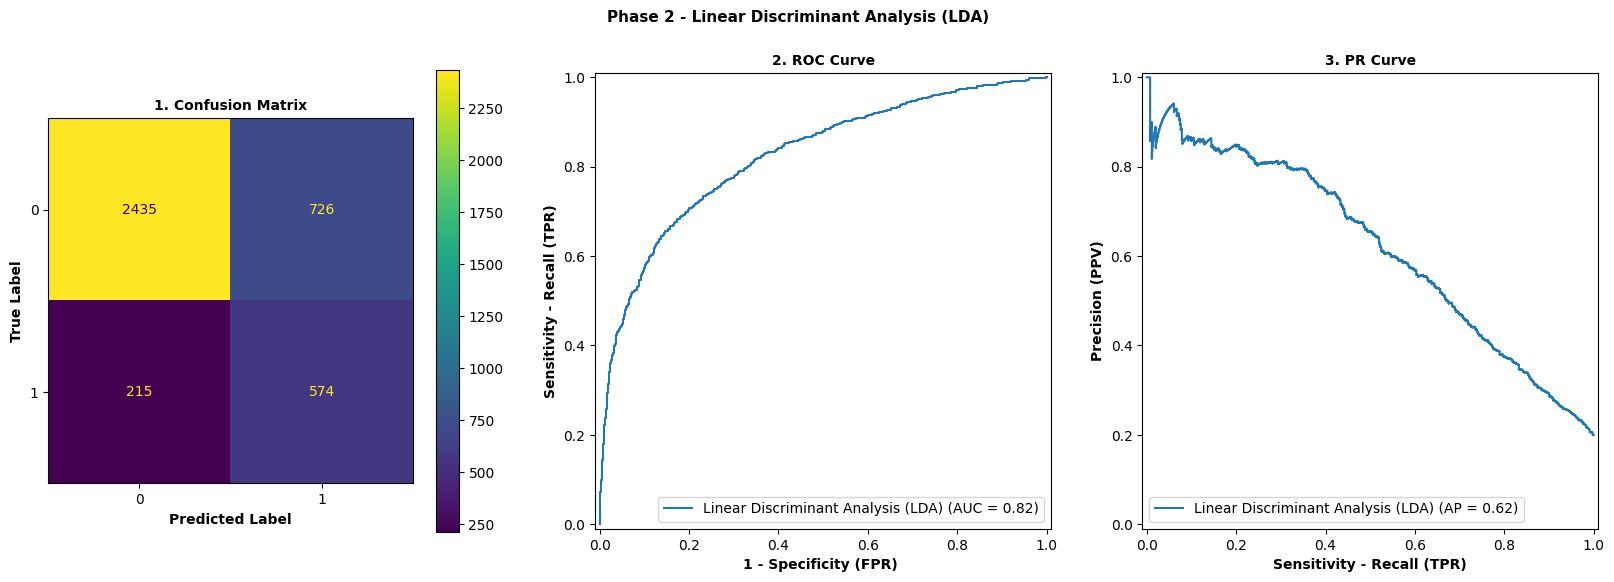

In [50]:
# Model
lda = LDA(store_covariance = True, solver = 'lsqr') # Use solver = lsqr if cv needed.

# HPO
param_grid = {
    "shrinkage" : [None, "auto"] + list(np.linspace(0.01, 1.0, 10)), # sklearn doc: float between 0 and 1
    'n_components' : np.arange(1, min(X_train.shape[1], len(np.unique(y_train)) - 1) + 1)
    } 
# CV
grid = GridSearchCV(estimator = lda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) 

# Final Model
lda_model = grid.fit(X_train, y_train) # automatically gives the best.estimator
print(f'Best Parameters : {lda_model.best_params_}')
print(f'Best Estimator : {lda_model.best_estimator_}')

# y_pred
y_pred_lda = lda_model.predict(X_test)

# Accuracy Score
ba_lda, class_lda, mcc_lda, f1_lda = accuracy(dfi, i, lda_model, X_test, y_test, y_pred_lda, "Linear Discriminant Analysis (LDA)")

# SHAP
# lda_shap = fun_shap(i, lda_model, X_test, 'LDA')

### QDA - Quantratic Discriminant Analysis
- QDA very sensistive to collinear data!
QDA and LDA assume Gaussian distributions.

"Best Parameters : {'reg_param': 0.0}"

'Best Estimator : QuadraticDiscriminantAnalysis(store_covariance=True)'

Model : Phase 2 - Quantric Discriminant Analysis (QDA)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.58      0.71      3161
           1       0.32      0.78      0.45       789

    accuracy                           0.62      3950
   macro avg       0.61      0.68      0.58      3950
weighted avg       0.79      0.62      0.66      3950


b).
F1 Score :
0.66

c).
Balanced Accuracy Score :
67.87%

d).
Matthews Correlation Coefficient (MCC) :
0.29

d).
Plots :
ROC AUC : 0.772
PR AUC : 0.521


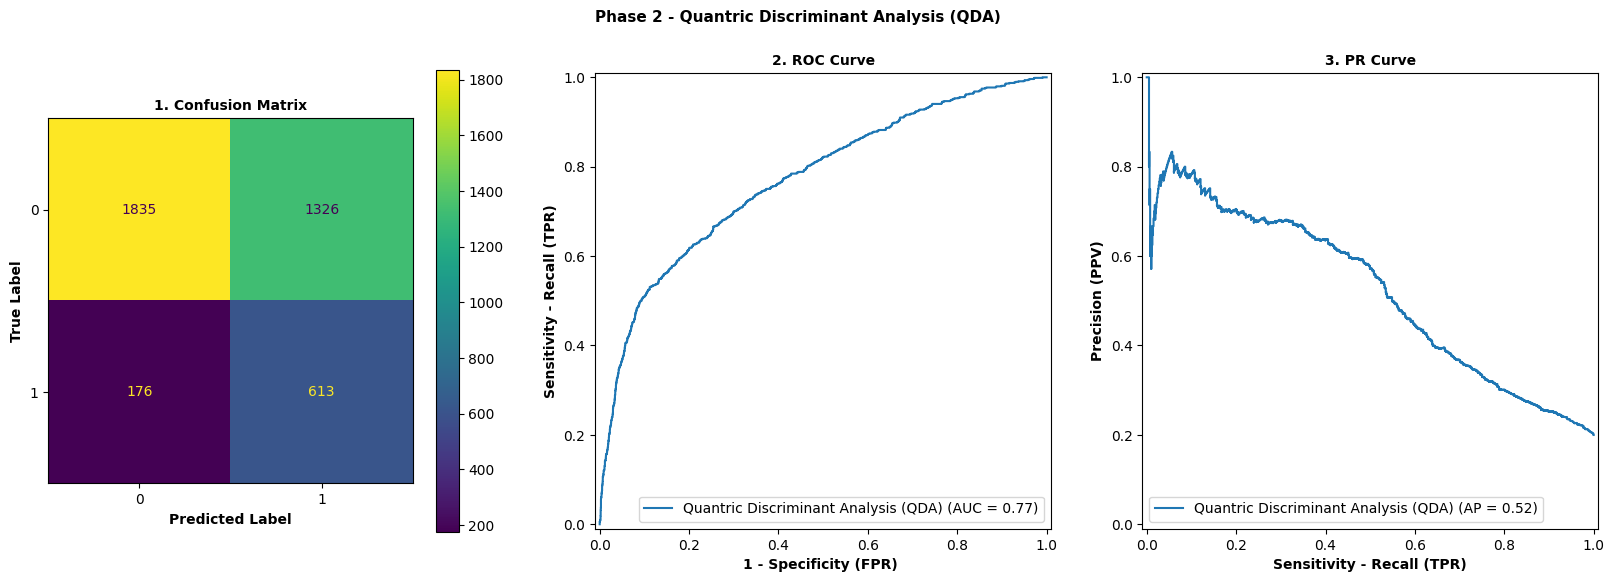

In [51]:
# Model
# QDA does not assume linear relation X - y --> lasso assumes. 
qda = QDA(store_covariance = True)

# HPO
param_grid = {
    "reg_param": np.linspace(0, 1, 30) # value range [0,1]
    }

# CV
grid = GridSearchCV(estimator = qda, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1) # cv = 5 default # n_jobs = -1 avoid overload

# Final model
qda_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {qda_model.best_params_}')
display(f'Best Estimator : {qda_model.best_estimator_}')

# y_pred
y_pred_qda = qda_model.predict(X_test)

# Accuracy Score
ba_qda, class_qda, mcc_qda, f1_qda = accuracy(dfi, i, qda_model, X_test, y_test, y_pred_qda, "Quantric Discriminant Analysis (QDA)")

# SHAP
# qda_shap = fun_shap(i, qda_model, X_test, 'QDA')


## B) ML Classification

### KNN - K Nearest Neighbors

"Best Parameters : {'n_neighbors': 83}"

'Best Estimator : KNeighborsClassifier(n_neighbors=83)'

Model : Phase 2 - K-Nearest Neighbors Classifier (KNN)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.90      0.37      0.53      3161
           1       0.25      0.84      0.39       789

    accuracy                           0.47      3950
   macro avg       0.58      0.61      0.46      3950
weighted avg       0.77      0.47      0.50      3950


b).
F1 Score :
0.50

c).
Balanced Accuracy Score :
60.73%

d).
Matthews Correlation Coefficient (MCC) :
0.18

d).
Plots :
ROC AUC : 0.693
PR AUC : 0.377


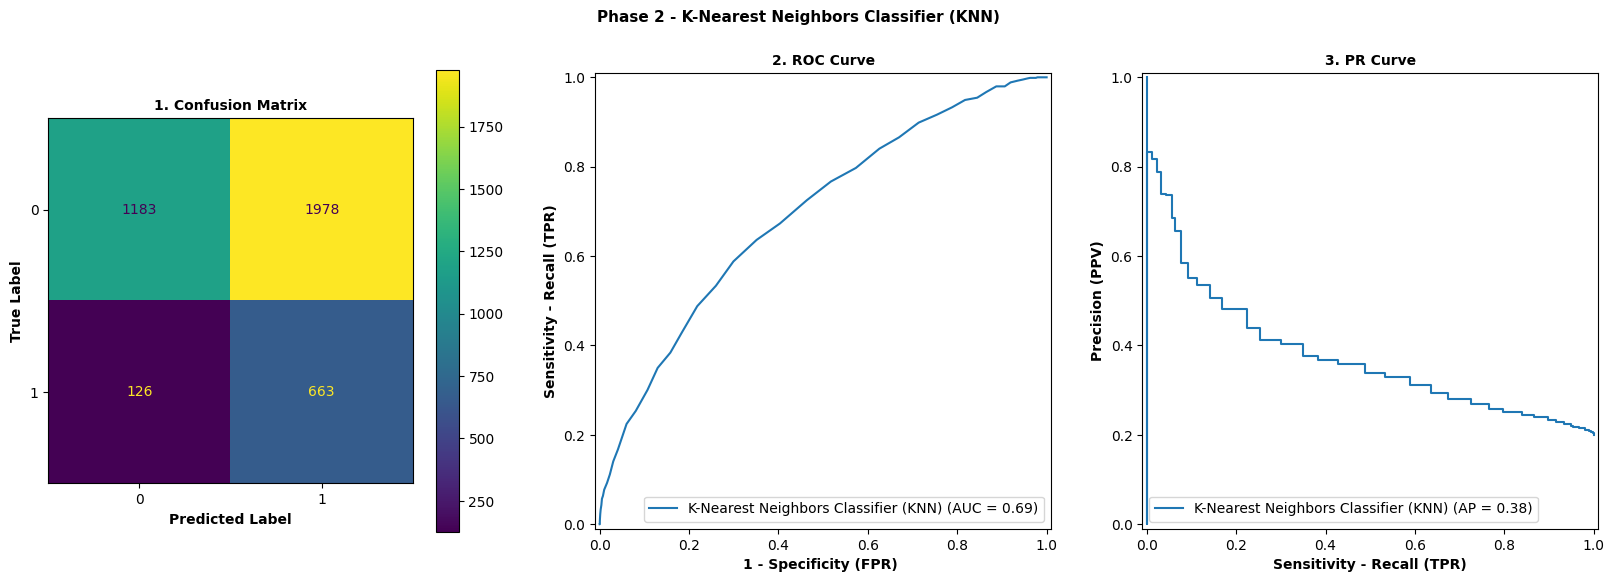

In [52]:
# Model 
knn = KNeighborsClassifier()

# HPO 
param_grid = {
    "n_neighbors" : np.linspace(5, 100, 30, endpoint = True).astype(int)
    } 

# CV
grid = GridSearchCV(estimator = knn , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
knn_model = grid.fit(X_train, y_train)
display(f'Best Parameters : {knn_model.best_params_}')
display(f'Best Estimator : {knn_model.best_estimator_}')

# y_pred
y_pred_knn = knn_model.predict(X_test)

# Accuracy Score
ba_knn, class_knn, mcc_knn, f1_knn = accuracy(dfi, i, knn_model, X_test, y_test, y_pred_knn, "K-Nearest Neighbors Classifier (KNN)")

# SHAP
# knn_shap = fun_shap(i, knn_model, X_test, 'KNN')

### SVC - Support Vector Classifier
- Always Chooses rbf
- poly is not going to be checked as it extremely increases compuational time, wihtout never be chosen. 
- rbf can find some non-linear boundries close to poly if needed. 


"Best Parameter: {'C': 21.544346900318832, 'gamma': 'auto'}"

"Best Estimator: SVC(C=21.544346900318832, class_weight='balanced', gamma='auto',\n    probability=True, random_state=42)"

Model : Phase 2 - Support Vector Classifier (SVC)

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.78      0.85      3161
           1       0.45      0.73      0.56       789

    accuracy                           0.77      3950
   macro avg       0.69      0.75      0.70      3950
weighted avg       0.83      0.77      0.79      3950


b).
F1 Score :
0.79

c).
Balanced Accuracy Score :
75.44%

d).
Matthews Correlation Coefficient (MCC) :
0.44

d).
Plots :
ROC AUC : 0.825
PR AUC : 0.617


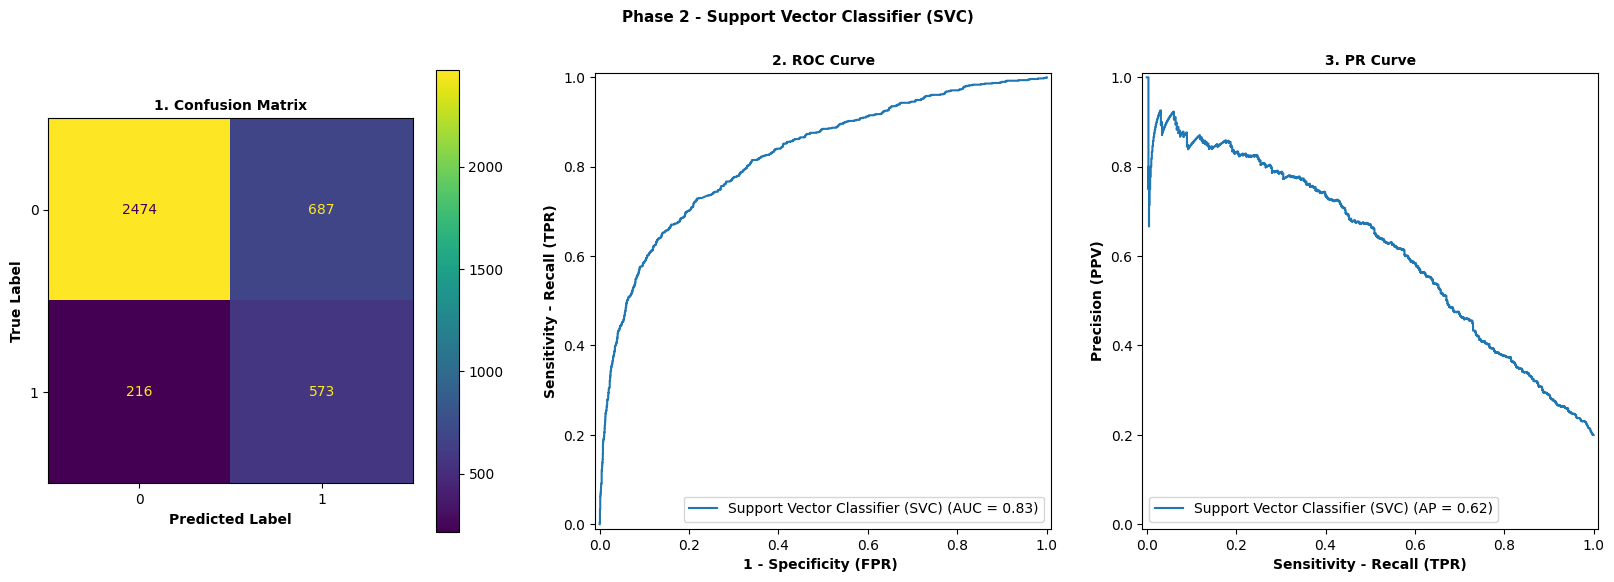

In [53]:
# Model
svc = SVC(probability = True, random_state = 42, class_weight = 'balanced', kernel = 'rbf')
 
# HPO
param_grid = {
    "C": np.logspace(0, 4, 10),
    "gamma": ["scale", "auto"]
}
# CV
grid = GridSearchCV(estimator = svc, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1,)

# Final Model
svc_model = grid.fit(X_train, y_train)
display(f'Best Parameter: {svc_model.best_params_}')
display(f'Best Estimator: {svc_model.best_estimator_}')

# y_pred
y_pred_svc = svc_model.predict(X_test)

# Accuracy Score
ba_svc, class_svc, mcc_svc, f1_svc = accuracy(dfi, i, svc_model, X_test, y_test, y_pred_svc, "Support Vector Classifier (SVC)")

# SHAP
# svc_shap = fun_shap(i, svc_model, X_test, 'SVC') # Hide for computational efficacy

### Random Forest

"Best Parameter criterion/bootstrap/n_estimators : {'bootstrap': True, 'criterion': 'gini', 'max_depth': 7, 'max_features': None}"

"Best Estimator : RandomForestClassifier(class_weight='balanced', max_depth=7, max_features=None,\n                       random_state=42)"

Model : Phase 2 - Random Forest Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.91      0.82      0.86      3161
           1       0.49      0.69      0.57       789

    accuracy                           0.79      3950
   macro avg       0.70      0.75      0.72      3950
weighted avg       0.83      0.79      0.81      3950


b).
F1 Score :
0.81

c).
Balanced Accuracy Score :
75.35%

d).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.821
PR AUC : 0.638


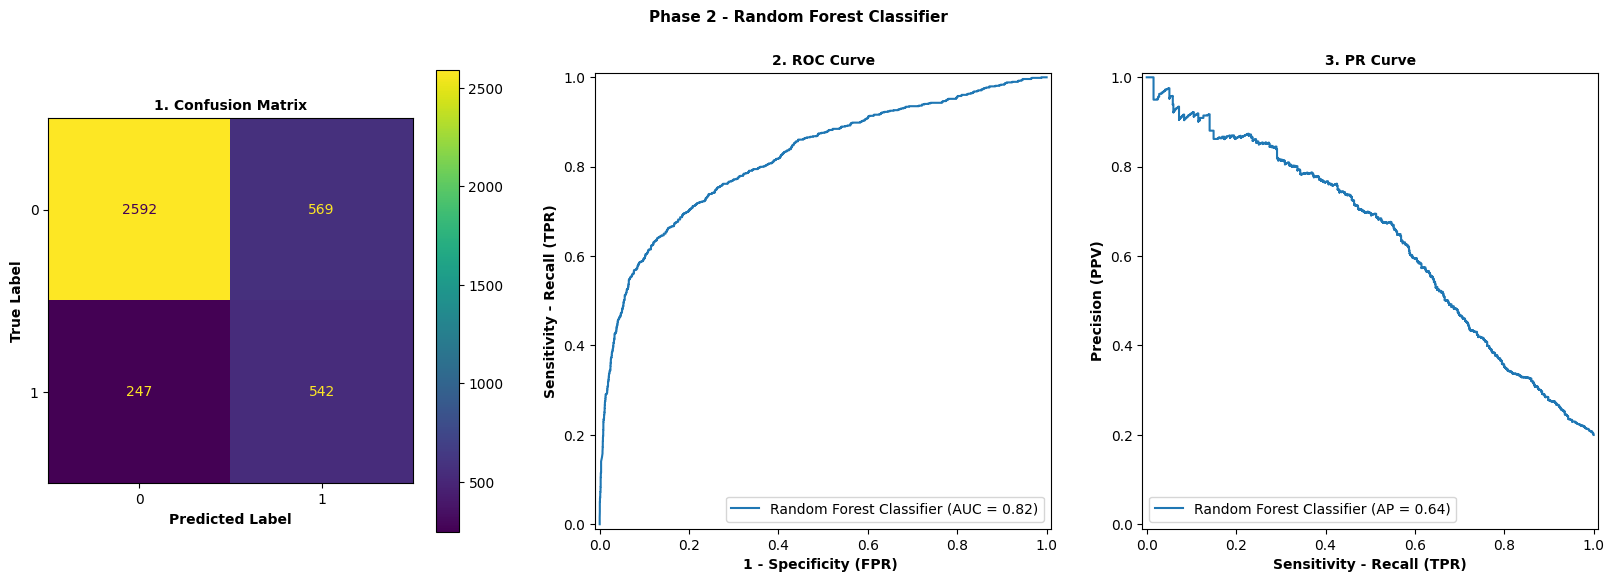

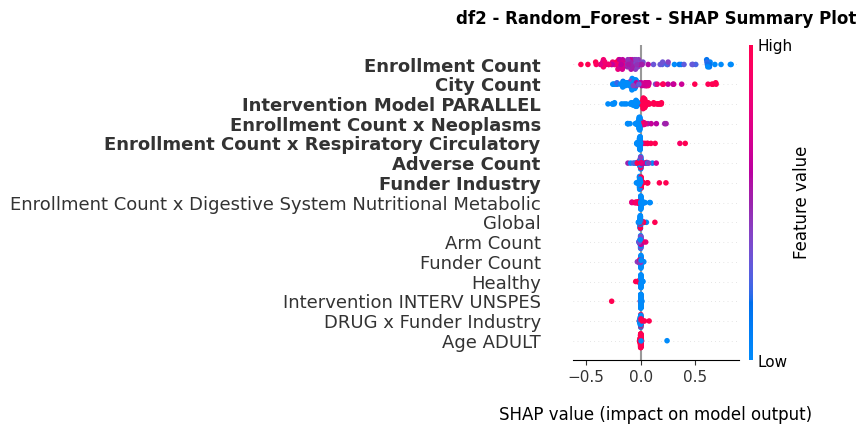

,Feature,df2_Random_Forest_Shap_Mean
0,Enrollment Count,0.249
1,City Count,0.130
2,Intervention Model PARALLEL,0.067
3,Enrollment Count x Neoplasms,0.027
4,Enrollment Count x Respiratory Circulatory,0.022
5,Adverse Count,0.015
6,Funder Industry,0.013
7,Enrollment Count x Digestive System Nutritiona...,0.013


In [54]:
# Model 
forest = RandomForestClassifier(random_state = 42, class_weight = 'balanced')

# CV
param_grid = {
    "criterion" : ['gini', 'entropy', 'log_loss'], 
    "bootstrap" : [True, False],  
# Bootstrap samples when building trees. If False, the whole dataset is used to build each tree.
    "max_features" : ["sqrt", "log2", None],  
# None = m = p = Bagging Random Forest. / sqrt = m = sqrt(p) = Classic Random Forest. / log2 = m = log2(p) = Other Random Forest.
    'max_depth': [3, 5, 7],
}

grid = GridSearchCV(estimator = forest , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
rf_model = grid.fit(X_train, y_train)
display(f'Best Parameter criterion/bootstrap/n_estimators : {rf_model.best_params_}')
display(f'Best Estimator : {rf_model.best_estimator_}')

# y_pred
y_pred_rf = rf_model.predict(X_test)

# Accuracy Score
ba_rf, class_rf, mcc_rf, f1_rf = accuracy(dfi, i, rf_model, X_test, y_test, y_pred_rf, "Random Forest Classifier")

# SHAP
rf_shap = fun_shap(i, rf_model, X_test, 'Random_Forest')

### Gradient Boosting Classifier

"Best Parameter learning_rate : {'learning_rate': 0.1, 'max_depth': 3, 'max_features': None, 'subsample': 0.6}"

'Best Estimator : GradientBoostingClassifier(random_state=42, subsample=0.6)'

Model : Phase 2 - Gradient Boosting Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.80      0.86      3161
           1       0.47      0.71      0.57       789

    accuracy                           0.78      3950
   macro avg       0.70      0.76      0.71      3950
weighted avg       0.83      0.78      0.80      3950


b).
F1 Score :
0.80

c).
Balanced Accuracy Score :
75.68%

d).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.832
PR AUC : 0.648


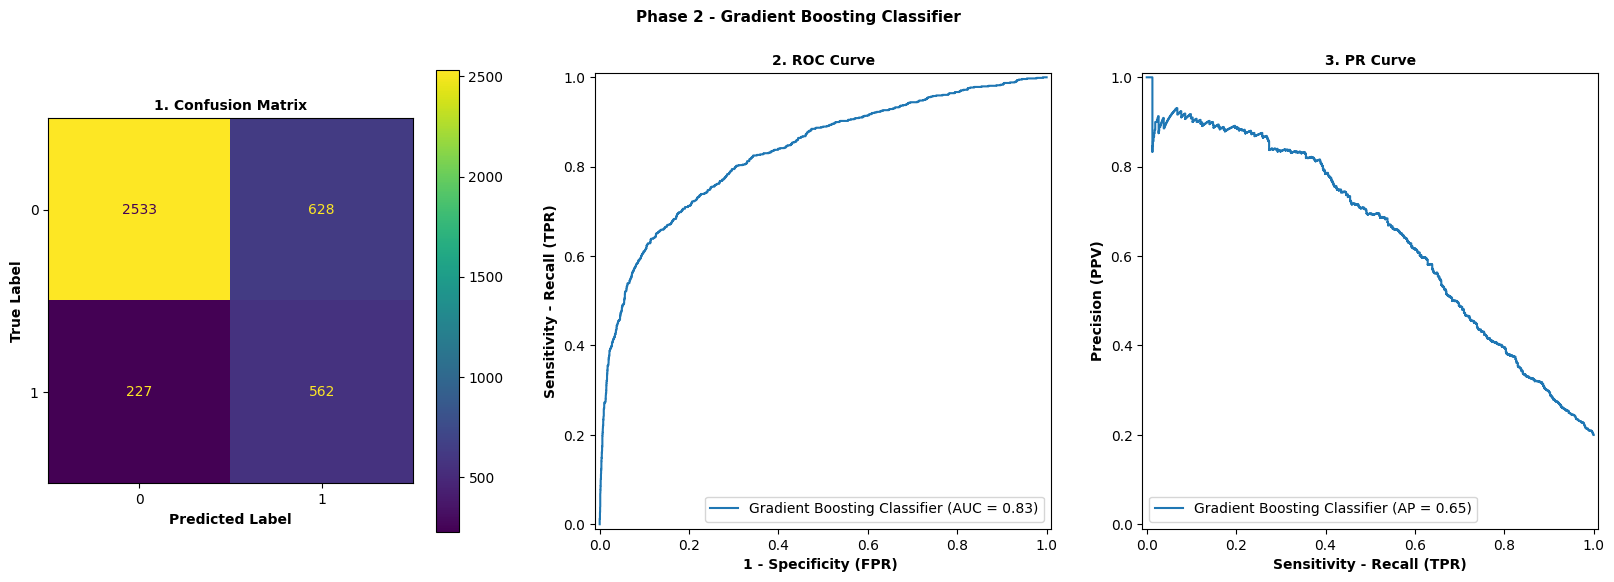

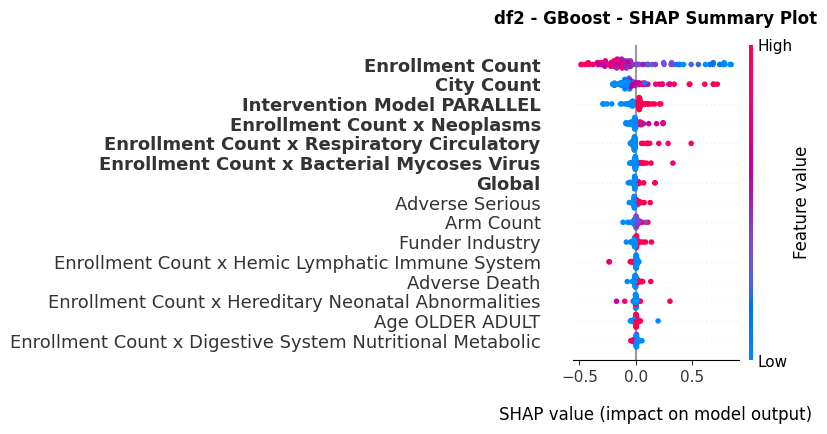

,Feature,df2_GBoost_Shap_Mean
0,Enrollment Count,0.259
1,City Count,0.121
2,Intervention Model PARALLEL,0.058
3,Enrollment Count x Neoplasms,0.033
4,Enrollment Count x Respiratory Circulatory,0.029
5,Enrollment Count x Bacterial Mycoses Virus,0.019
6,Global,0.017
7,Adverse Serious,0.016


In [55]:
# Model (+10 mins)
gra_boost = GradientBoostingClassifier(random_state = 42, loss = 'log_loss')  

#loss : {'log_loss', 'exponential'}, default='log_loss'
# The loss function to be optimized. 'log_loss' refers to binomial and multinomial deviance, the same as used in logistic regression. 
# It is a good choice for classification with probabilistic outputs. For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
    'subsample': [0.6, 1.0],
    "max_features" : ["sqrt", "log2", None],  
    }

grid = GridSearchCV(estimator = gra_boost , param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
gb_model = grid.fit(X_train, y_train)
display(f'Best Parameter learning_rate : {gb_model.best_params_}')
display(f'Best Estimator : {gb_model.best_estimator_}')

# y_pred
y_pred_gb = gb_model.predict(X_test)

# Accuracy Score
ba_gb, class_gb, mcc_gb, f1_gb = accuracy(dfi, i, gb_model, X_test, y_test, y_pred_gb, "Gradient Boosting Classifier")

# SHAP
gb_shap = fun_shap(i, gb_model, X_test, 'GBoost')

### Extreme Gradient Boost

Best Parameters: {'gamma': 0.5, 'learning_rate': 0.1, 'max_depth': 3, 'subsample': 1.0}
Model : Phase 2 - XGBoosting Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.82      0.86      3161
           1       0.49      0.70      0.57       789

    accuracy                           0.79      3950
   macro avg       0.70      0.76      0.72      3950
weighted avg       0.83      0.79      0.80      3950


b).
F1 Score :
0.80

c).
Balanced Accuracy Score :
75.74%

d).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.83
PR AUC : 0.635


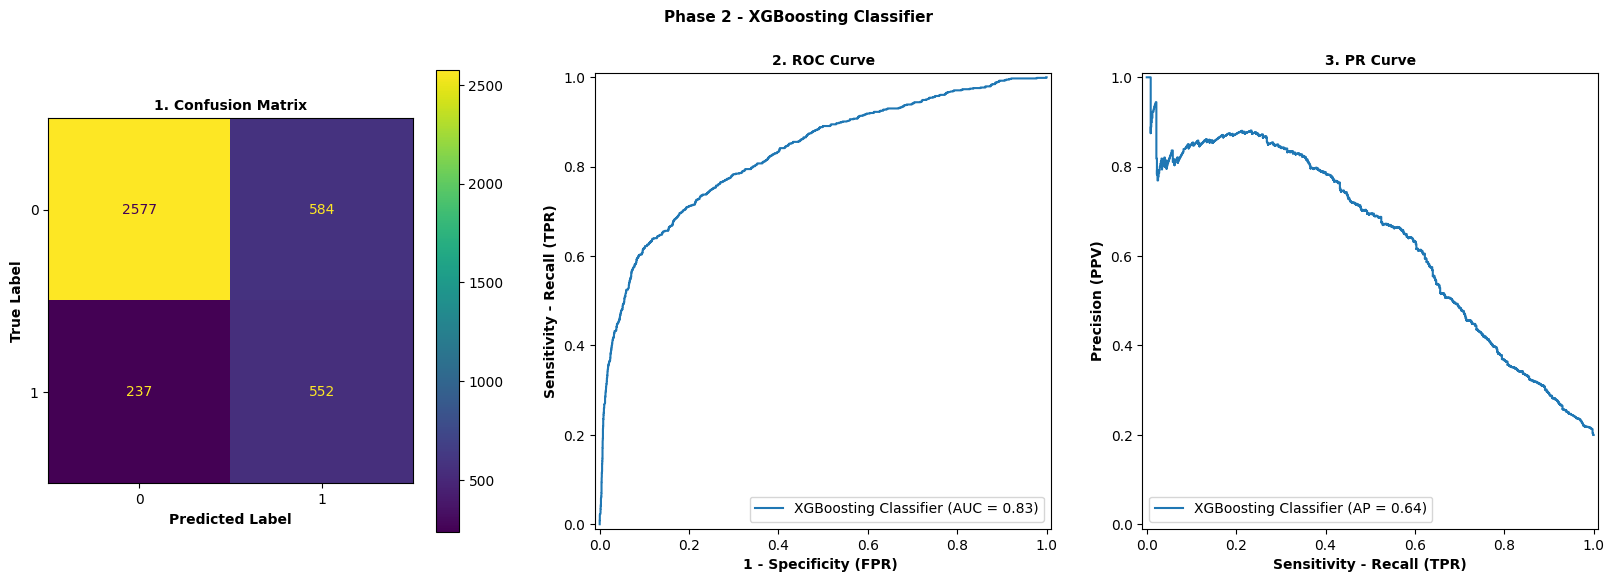

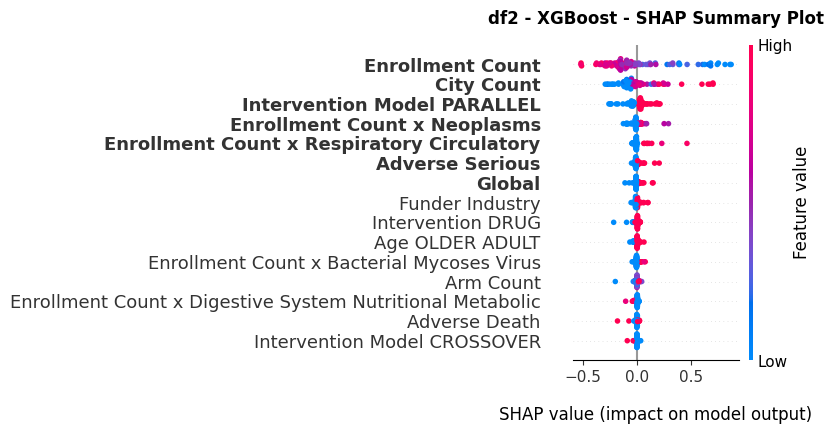

,Feature,df2_XGBoost_Shap_Mean
0,Enrollment Count,0.246
1,City Count,0.125
2,Intervention Model PARALLEL,0.063
3,Enrollment Count x Neoplasms,0.030
4,Enrollment Count x Respiratory Circulatory,0.024
5,Global,0.016
6,Adverse Serious,0.016
7,Funder Industry,0.014


In [56]:
# Model
xgb = XGBClassifier(objective = 'binary:logistic', eval_metric = 'logloss', random_state = 42) 
# Doc: For classification, ‘log_loss’.

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
    #'colsample_bytree': [0.5, 0.7, 1.0],
    'subsample': [0.6, 1.0],
    'gamma': [0, 0.1, 0.5]
    }

grid = GridSearchCV(estimator = xgb, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
xgb_model = grid.fit(X_train, y_train)
print("Best Parameters:", xgb_model.best_params_)
# print("Best Estimator:", xgb_model.best_estimator_) # too long output. 

# y_pred
y_pred_xgb = xgb_model.predict(X_test)

# Accuracy Score
ba_xgb, class_xgb, mcc_xgb, f1_xgb = accuracy(dfi, i, xgb_model, X_test, y_test, y_pred_xgb, "XGBoosting Classifier")

# SHAP
xgb_shap = fun_shap(i, xgb_model, X_test, 'XGBoost')

### LightBoost

Best Parameters: {'learning_rate': 0.1, 'max_depth': 5, 'min_child_samples': 100, 'num_leaves': 10, 'subsample': 0.6}
Model : Phase 2 - LightGBM Classifier

a).
Classification Report :
              precision    recall  f1-score   support

           0       0.92      0.81      0.86      3161
           1       0.48      0.70      0.57       789

    accuracy                           0.79      3950
   macro avg       0.70      0.76      0.72      3950
weighted avg       0.83      0.79      0.80      3950


b).
F1 Score :
0.80

c).
Balanced Accuracy Score :
75.60%

d).
Matthews Correlation Coefficient (MCC) :
0.45

d).
Plots :
ROC AUC : 0.831
PR AUC : 0.645


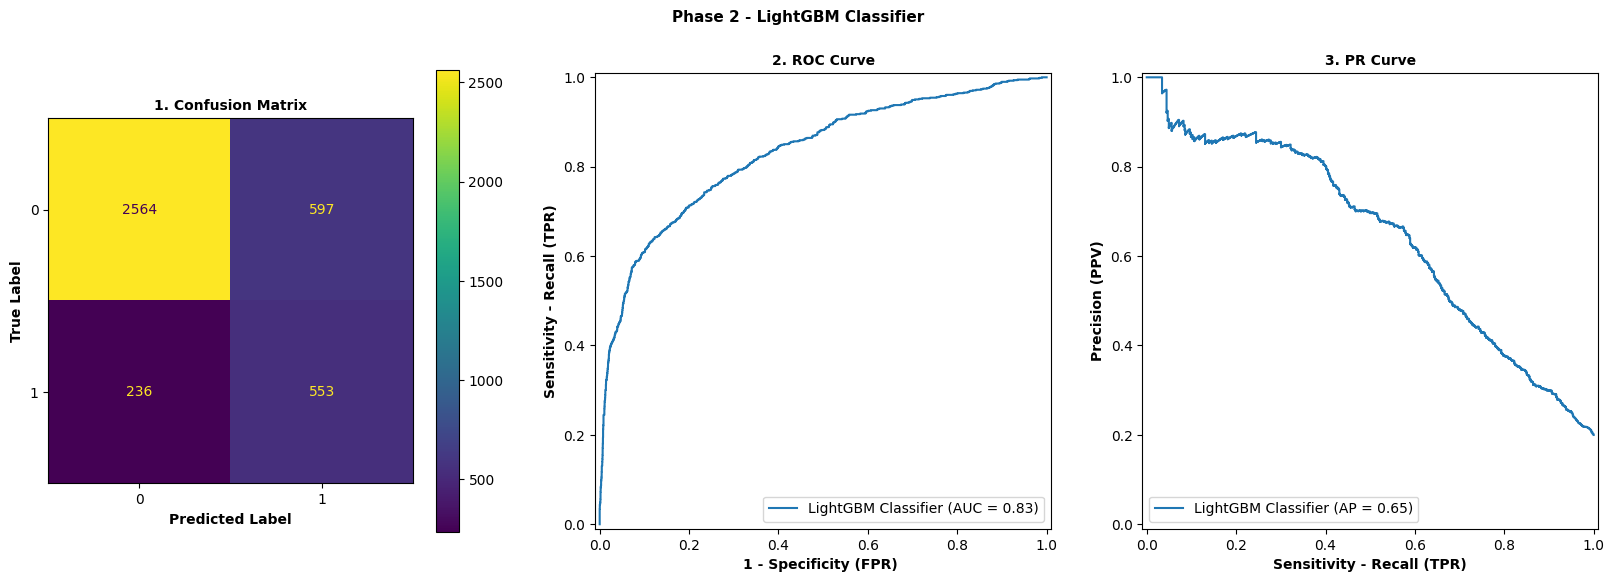

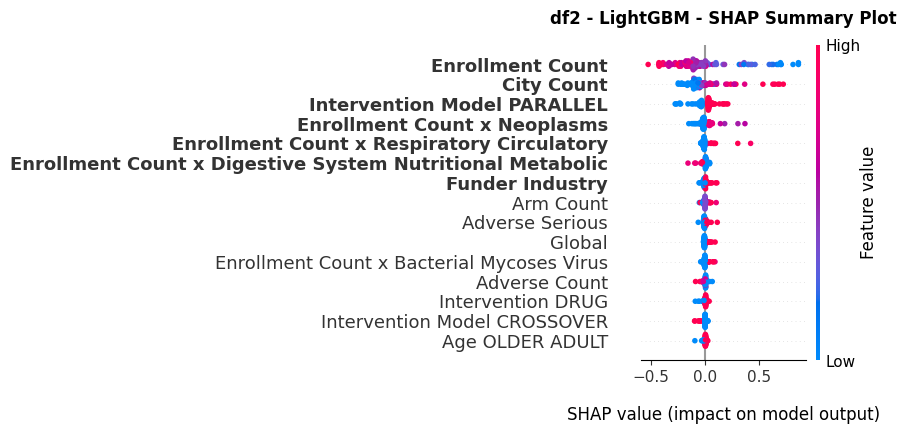

,Feature,df2_LightGBM_Shap_Mean
0,Enrollment Count,0.242
1,City Count,0.130
2,Intervention Model PARALLEL,0.064
3,Enrollment Count x Neoplasms,0.039
4,Enrollment Count x Respiratory Circulatory,0.024
5,Enrollment Count x Digestive System Nutritiona...,0.016
6,Funder Industry,0.014
7,Arm Count,0.012


In [57]:
# Model
lgb = LGBMClassifier(objective = 'binary', random_state = 42, n_jobs=-1, metric = 'binary_logloss', 
                     class_weight = 'balanced', verbose = -1) 
# Doc: For classification, ‘log_loss’.

# CV
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
    #'colsample_bytree': [0.5, 0.7, 1.0],
    'subsample': [0.6, 1.0], 
    'num_leaves': [10, 30, 50],
    'min_child_samples': [20, 50, 100], 
}

grid = GridSearchCV(estimator = lgb, param_grid = param_grid, scoring = 'roc_auc', cv = 5, n_jobs = -1)

# Final Model
lgb_model = grid.fit(X_train, y_train)
print("Best Parameters:", lgb_model.best_params_)

# y_pred
y_pred_lgb = lgb_model.predict(X_test)

# Accuracy Score
ba_lgb, class_lgb, mcc_lgb, f1_lgb = accuracy(dfi, i, lgb_model, X_test, y_test, y_pred_lgb, "LightGBM Classifier")

# SHAP
lgb_shap = fun_shap(i, lgb_model, X_test, 'LightGBM')

# ROC Curve

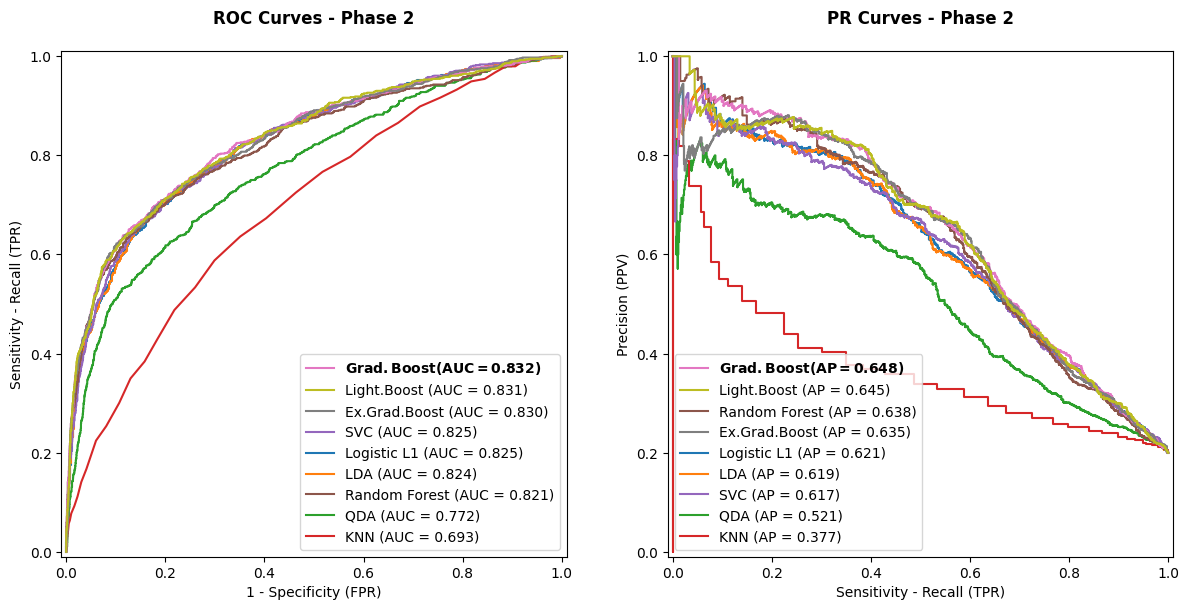

In [58]:
# Save Path
folder_roc = "roc_plots"
os.makedirs(folder_roc, exist_ok=True)
filename = f"roc_df{i}.png"
filepath = os.path.join(folder_roc, filename)

# Models
models = [
    ("Logistic L1", log_model, X_test, y_test),
    ("LDA", lda_model, X_test, y_test),
    ("QDA", qda_model, X_test, y_test),
    ("KNN", knn_model, X_test, y_test),
    ("SVC", svc_model, X_test, y_test),
    ("Random Forest", rf_model, X_test, y_test),
    ("Grad.Boost", gb_model, X_test, y_test),
    ("Ex.Grad.Boost", xgb_model, X_test, y_test),
    ("Light.Boost", lgb_model, X_test, y_test)
]

fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(12, 6))

roc_aucs = []
pr_aucs = []

for original_name, model, X_test_model, y_test_model in models:
    y_score = model.predict_proba(X_test_model)[:, 1]  

# ROC Curve
    auc = roc_auc_score(y_test_model, y_score)
    label_roc = f"{original_name} (AUC = {auc:.3f})"
    roc = RocCurveDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_roc,
        name=label_roc, # pos_label = 1  # Completed = 0, Terminated = 1
    )
    roc_aucs.append((auc, label_roc, roc.line_))

# PR Curve
    ap = average_precision_score(y_test_model, y_score)
    label_pr = f"{original_name} (AP = {ap:.3f})"
    pr = PrecisionRecallDisplay.from_estimator(
        model, X_test_model, y_test_model, ax=ax_pr,
        name=label_pr# , pos_label=1
    )
    pr_aucs.append((ap, label_pr, pr.line_))

# Sort models at legends
roc_aucs.sort(key=lambda x: x[0], reverse=True)
pr_aucs.sort(key=lambda x: x[0], reverse=True)

# Bold best model
roc_handles = [item[2] for item in roc_aucs]
roc_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(roc_aucs)]
ax_roc.legend(roc_handles, roc_labels, loc = "lower right")

pr_handles = [item[2] for item in pr_aucs]
pr_labels = [f"$\\bf{{{item[1]}}}$" if i == 0 else item[1] for i, item in enumerate(pr_aucs)]
ax_pr.legend(pr_handles, pr_labels, loc = "lower left")

# Titles/ labels
ax_roc.set_title(f"ROC Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_roc.set_xlabel("1 - Specificity (FPR)", fontsize = 10)
ax_roc.set_ylabel("Sensitivity - Recall (TPR)", fontsize = 10)

ax_pr.set_title(f"PR Curves - Phase {i}", fontsize = 12, fontweight = 'bold', pad = 20)
ax_pr.set_ylabel("Precision (PPV)", fontsize = 10)
ax_pr.set_xlabel("Sensitivity - Recall (TPR)", fontsize = 10)

plt.tight_layout()
plt.subplots_adjust(wspace=0.2) 

# Save Plot
plt.savefig(filepath, dpi=100, bbox_inches="tight")
plt.show()
plt.close()

# Metrics
= MCC [-1, 1]
- MCC = 0 = Random Guessing 

In [59]:
MCC = pd.DataFrame({
        'Models': ['Logistic', 'LDA', 'QDA', 'KNN', 'SVC', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'MCC': [mcc_log, mcc_lda, mcc_qda, mcc_knn, mcc_svc, mcc_rf, mcc_gb, mcc_xgb, mcc_lgb]  # mcc_el, mcc_tr
                }).sort_values(by = 'MCC', ascending = False)

BACC = pd.DataFrame({
        'Models': ['Logistic', 'LDA', 'QDA', 'KNN', 'SVC', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'BACC': [ba_log, ba_lda, ba_qda, ba_knn, ba_svc, ba_rf, ba_gb, ba_xgb, ba_lgb]  # ba_el, ba_tr
                }).sort_values(by = 'BACC', ascending = False)

F1 = pd.DataFrame({
        'Models': ['Logistic', 'LDA', 'QDA', 'KNN', 'SVC', 'Random_Forest', 'Grad_Boost', 
                   'Ex_Grad_Boost', 'LightGBM'],\
        'F1': [f1_log, f1_lda, f1_qda, f1_knn, f1_svc, f1_rf, f1_gb, f1_xgb, f1_lgb]  # f1_el, f1_tr
                }).sort_values(by = 'F1', ascending = False)

metrics = pd.merge(BACC, MCC, on = 'Models')
metrics = pd.merge(metrics, F1, on = 'Models')
metrics = metrics.sort_values(by = ['MCC', 'BACC', 'F1'], ascending = False)
metrics.index.name = f'df{i}'
metrics

first_idx = metrics.index[0]
metrics.loc[first_idx] = metrics.loc[first_idx].apply(lambda x: f"**{x}**")
metrics
# from IPython.display import display, Markdown
# display(Markdown(metrics.to_markdown(index=True)))


,Models,BACC,MCC,F1
df2,,,,
0,**Ex_Grad_Boost**,**75.74%**,**0.45**,**0.80**
1,Grad_Boost,75.68%,0.45,0.80
2,LightGBM,75.60%,0.45,0.80
4,Random_Forest,75.35%,0.45,0.81
3,SVC,75.44%,0.44,0.79
5,Logistic,74.92%,0.42,0.78
6,LDA,74.89%,0.42,0.78
7,QDA,67.87%,0.29,0.66
8,KNN,60.73%,0.18,0.50


# Logistic Interpretention

In [60]:
X = X_test[xgb_shap['Feature'].to_list()]
display(xgb_shap)

X = sm.add_constant(X)
y = y_test

model = sm.Logit(y, X)
results = model.fit(method = 'lbfgs', maxiter = 1000)
print(results.summary())
print("\n")

,Feature,df2_XGBoost_Shap_Mean
0,Enrollment Count,0.246
1,City Count,0.125
2,Intervention Model PARALLEL,0.063
3,Enrollment Count x Neoplasms,0.030
4,Enrollment Count x Respiratory Circulatory,0.024
5,Global,0.016
6,Adverse Serious,0.016
7,Funder Industry,0.014


                           Logit Regression Results                           
Dep. Variable:           Study Status   No. Observations:                 3950
Model:                          Logit   Df Residuals:                     3941
Method:                           MLE   Df Model:                            8
Date:                Tue, 18 Nov 2025   Pseudo R-squ.:                  0.2546
Time:                        16:33:12   Log-Likelihood:                -1472.3
converged:                       True   LL-Null:                       -1975.2
Covariance Type:            nonrobust   LLR p-value:                7.946e-212
                                                 coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------------
const                                          1.3818      0.131     10.527      0.000       1.125       1.639
Enrollment Count                   

# Save Metrics

In [61]:
metrics.to_pickle(f"./shap_plots/df{i}_metrics.pkl")

# Time

In [62]:
end_time = time.time()
elapsed_minutes = (end_time - start_time) / 60
print(f"df{i} - Execution time: {elapsed_minutes:.0f} minutes")

df2 - Execution time: 11 minutes
